In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/Studia-II/Uczenie-Maszynowe/Lista6/Zad1

In [17]:
import numpy as np
import matplotlib.pyplot as plt

d = 2 
N = 100 
mu = np.zeros(d) 
sigma_1 = 0.01 * np.eye(d)

set_normal = np.random.multivariate_normal(mu, sigma_1, N)

set_uniform_sphere = np.random.normal(0, 1, size=(N, d))

norms = np.linalg.norm(set_uniform_sphere, axis=1, keepdims=True)
set_sphere = set_uniform_sphere / norms

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


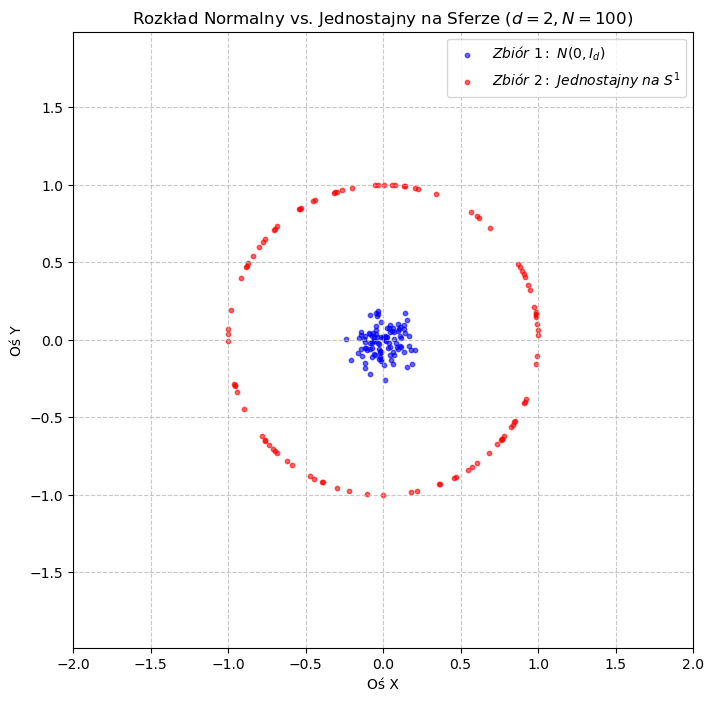

In [18]:
plt.figure(figsize=(8, 8))

plt.scatter(
    set_normal[:, 0], set_normal[:, 1], 
    s=10, 
    alpha=0.6, 
    label=r'$Zbiór\ 1:\ N(0, I_d)$', 
    color='blue'
)

plt.scatter(
    set_sphere[:, 0], set_sphere[:, 1], 
    s=10, 
    alpha=0.6, 
    label=r'$Zbiór\ 2:\ Jednostajny\ na\ S^{1}\ $', 
    color='red'
)

plt.title(f'Rozkład Normalny vs. Jednostajny na Sferze ($d={d}, N={N}$)')
plt.xlabel('Oś X')
plt.ylabel('Oś Y')
plt.axis('equal') 
plt.xlim(-2, 2) 
plt.ylim(-2, 2)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

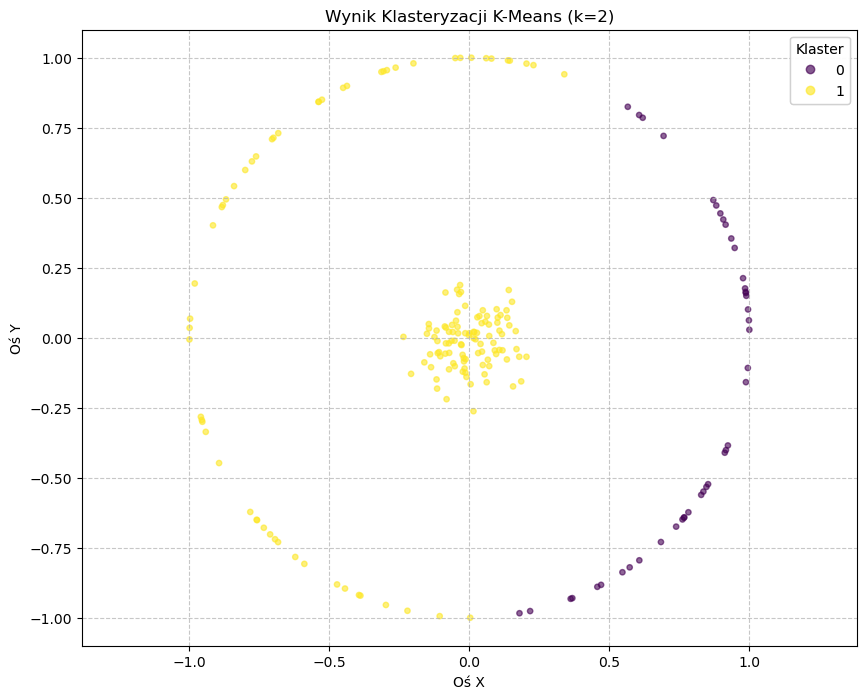

In [19]:
from sklearn.cluster import KMeans

data = np.vstack((set_normal, set_sphere))

k = 2
kmeans = KMeans(n_clusters=k, random_state=2137, n_init=10)
labels = kmeans.fit_predict(data)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    data[:, 0], data[:, 1], 
    c=labels, 
    s=15, 
    cmap='viridis', 
    alpha=0.6, 
    label='Punkty Klasteryzowane'
)

legend1 = plt.legend(*scatter.legend_elements(), 
                        loc="upper right", 
                        title="Klaster")
plt.gca().add_artist(legend1)

plt.title(f'Wynik Klasteryzacji K-Means (k={k})')
plt.xlabel('Oś X')
plt.ylabel('Oś Y')
plt.axis('equal') 
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
